# Everything matters...also in machine learning: </br> some pointers from ReproNim

<img align="right" src="https://www.repronim.org/images/logo-square-256.png" alt="logo" title="Twitter" width="200"/>


[Peer Herholz (he/him)](https://peerherholz.github.io/)   
Research Assistant Professor - [Northwestern University](https://www.northwestern.edu/)  
Research affiliate - [NeuroDataScience lab](https://neurodatascience.github.io/) at [MNI](https://www.mcgill.ca/neuro/)/[McGill](https://www.mcgill.ca/),  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[UNIQUE](https://sites.google.com/view/unique-neuro-ai),  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[Max-Planck-Institute for Human Cognitive and Brain Sciences](https://www.cbs.mpg.de/en)  
Member - [BIDS](https://bids-specification.readthedocs.io/en/stable/), [ReproNim](https://www.repronim.org/), [Brainhack](https://brainhack.org/), [Neuromod](https://www.cneuromod.ca/), [OHBM SEA-SIG](https://ohbm-environment.org/)

<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/7a/Bluesky_Logo.svg/1200px-Bluesky_Logo.svg.png" alt="logo" title="Bluesky" width="30" height="30" /> 
<img align="left" src="https://raw.githubusercontent.com/G0RELLA/gorella_mwn/master/lecture/static/GitHub-Mark-120px-plus.png" alt="logo" title="Github" width="30" height="30" /> 
<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/48/Mastodon_Logotype_%28Simple%29.svg/432px-Mastodon_Logotype_%28Simple%29.svg.png" alt="logo" title="Mastodon" width="30" height="30" />
<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c7/Google_Scholar_logo.svg/1024px-Google_Scholar_logo.svg.png" alt="logo" title="Google scholar" width="30" height="30" />
<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/Spotify_logo_without_text.svg/1920px-Spotify_logo_without_text.svg.png" alt="logo" title="Spotify" width="30" height="30" />&nbsp;&nbsp;@peerherholz  

Interactive version (please select the `gh-pages` `branch`):   
<a target="_blank" href="https://colab.research.google.com/github/PeerHerholz/repronim_ML">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


Let's imagine the following scenario:

Your PI tells you to run some `machine learning` analyses on your data (because buzz words and we all need top tier publications and that sweet grant money). Specifically, you should use `resting state connectivity` data to predict the `age` of `participants` (sounds familiar, eh?). So you go ahead, gather some data, apply a `random forest` (a form of `decision tree`) and ...   

Whoa, let's go back a few steps and actually briefly define what we're talking about here, starting with `machine learning`.

<img align="center"  src="https://raw.githubusercontent.com/PeerHerholz/ML-DL_workshop_SynAGE/master/lecture/static/AI_ML_DL.png" alt="logo" title="Twitter" width="600"/>

and also its `components` & `steps`:

<img align="center"  src="https://raw.githubusercontent.com/PeerHerholz/ML-DL_workshop_SynAGE/master/lecture/static/core_aspects_metric.png" alt="logo" title="Twitter" width="800"/>


Of course, also `reproducibility`:

<img align="center"  src="https://book.the-turing-way.org/build/reproducible-matrix-f64551d0976976dd286c541fbc33e4bb.jpg" alt="logo" title="Twitter" width="800"/>

via [The Turing Way](https://book.the-turing-way.org/build/reproducible-matrix-1f714c1d292747c95fe172a47d6a0937.jpg).

Now, let's actually check how this looks like. At first we get the `data`:

In [1]:
import urllib.request

url = 'https://www.dropbox.com/s/v48f8pjfw4u2bxi/MAIN_BASC064_subsamp_features.npz?dl=1'
urllib.request.urlretrieve(url, 'MAIN2019_BASC064_subsamp_features.npz')

('MAIN2019_BASC064_subsamp_features.npz',
 <http.client.HTTPMessage at 0x10823ff10>)

and then inspect it:

In [2]:
import numpy as np

data = np.load('MAIN2019_BASC064_subsamp_features.npz')['a']
data.shape

(155, 2016)

We will also `visualize` it to better grasp what's going on:

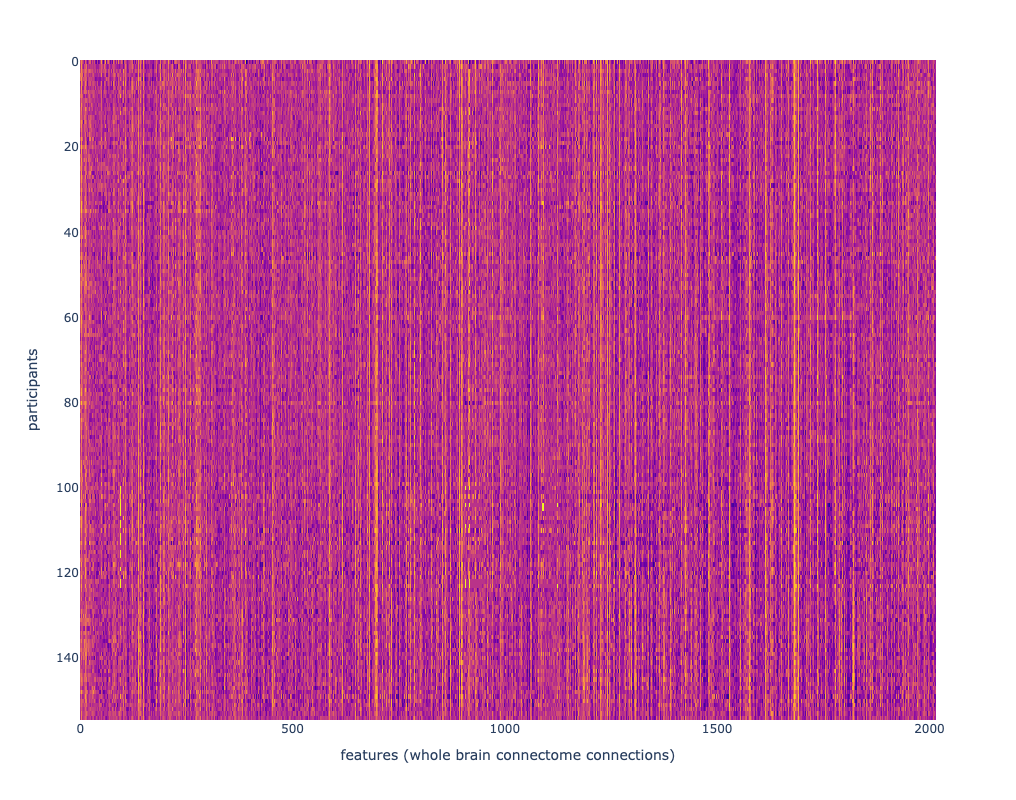

In [3]:
import plotly.express as px
from IPython.display import display, HTML
from plotly.offline import init_notebook_mode, plot

fig = px.imshow(data, labels=dict(x="features (whole brain connectome connections)", y="participants"), 
                height=800, aspect='None')

fig.update(layout_coloraxis_showscale=False)
init_notebook_mode(connected=True)

fig.show()

#plot(fig, filename = 'input_data.html')
#display(HTML('input_data.html'))

Beside the `input data` we also need our `labels`:

In [4]:
url = 'https://www.dropbox.com/s/ofsqdcukyde4lke/participants.csv?dl=1'
urllib.request.urlretrieve(url, 'participants.csv')

('participants.csv', <http.client.HTTPMessage at 0x117c13fd0>)

Which we then `load` and `check` as well:

In [5]:
import pandas as pd
labels = pd.read_csv('participants.csv')['AgeGroup']
labels.describe()

count     155
unique      6
top       5yo
freq       34
Name: AgeGroup, dtype: object

For a better intuition, we’re going to also `visualize` the `labels` and their `distribution`:

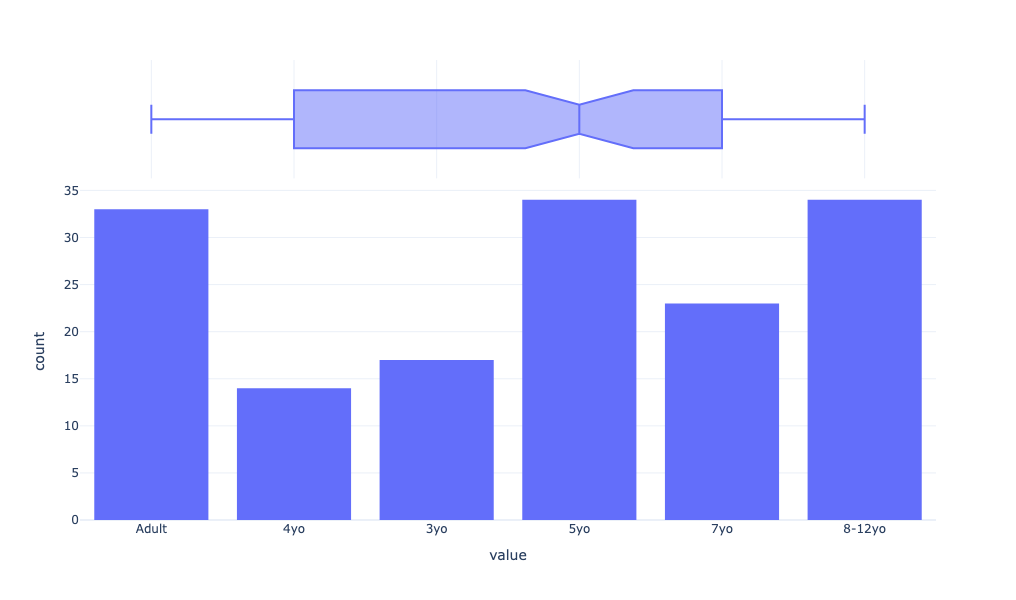

In [6]:
fig = px.histogram(labels, marginal='box', template='plotly_white')

fig.update_layout(showlegend=False, width=800, height=600)
init_notebook_mode(connected=True)

fig.show()

#plot(fig, filename = 'labels.html')
#display(HTML('labels.html'))

And we’re ready to create our `machine learning analysis pipeline` using [scikit-learn]() within we will `scale` our `input data`, `train` a [Random Forest]() and test its `predictive performance`. We import the required `functions` and `classes`:

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupShuffleSplit, cross_validate, cross_val_score
from sklearn.metrics import accuracy_score

and setup an `scikit-learn` [pipeline]():

In [8]:
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier()
)

That's all we need to run the `analysis`, computing `accuracy` and `mean absolute error`:

In [9]:
acc_val_rf = cross_validate(pipe, data, pd.Categorical(labels).codes, cv=10, return_estimator =True)
acc_rf = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=10)
mae_rf = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=10, 
                         scoring='neg_mean_absolute_error')

which we can then inspect for each `CV fold`:

In [10]:
for i in range(10):
    print(
        'Fold {} -- Acc = {}, MAE = {}'.format(i, np.round(acc_rf[i], 3), np.round(-mae_rf[i], 3))
    )

Fold 0 -- Acc = 0.438, MAE = 1.062
Fold 1 -- Acc = 0.562, MAE = 0.875
Fold 2 -- Acc = 0.5, MAE = 1.5
Fold 3 -- Acc = 0.562, MAE = 1.062
Fold 4 -- Acc = 0.562, MAE = 1.188
Fold 5 -- Acc = 0.533, MAE = 1.267
Fold 6 -- Acc = 0.6, MAE = 0.8
Fold 7 -- Acc = 0.667, MAE = 0.933
Fold 8 -- Acc = 0.467, MAE = 0.533
Fold 9 -- Acc = 0.4, MAE = 1.333


and overall:

In [11]:
print('Accuracy = {}, MAE = {}, Chance = {}'.format(np.round(np.mean(acc_rf), 3), 
                                                    np.round(np.mean(-mae_rf), 3), 
                                                    np.round(1/len(labels.unique()), 3)))

Accuracy = 0.529, MAE = 1.055, Chance = 0.167


That's a pretty good performance, eh? The amazing power of `machine learning`! But there's more: you also try out an `ANN` to see if it's providing even better `predictions`. 

That's as easy as the "basic `machine learning pipeline`". Just `import` the respective `functions` and `classes`:

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2025-06-17 17:46:51.623493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Define a simple `ANN` with `4 layers`:

In [13]:
model = keras.Sequential()

model.add(layers.Input(shape=data[1].shape))
model.add(layers.Dense(100, activation="relu", kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(50, activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(25, activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(len(labels.unique()), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', 
              metrics=['accuracy'])


Split the `data` into `train` and `test` again:

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, pd.Categorical(labels).codes, test_size=0.2, shuffle=True)

and `train` your `model`:

In [15]:
%time fit = model.fit(X_train, y_train, epochs=300, batch_size=20, validation_split=0.2)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.1772 - loss: 2.7513 - val_accuracy: 0.0800 - val_loss: 1.7977
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1637 - loss: 2.6742 - val_accuracy: 0.1600 - val_loss: 1.8318
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1447 - loss: 2.4660 - val_accuracy: 0.2000 - val_loss: 1.8271
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2952 - loss: 2.2985 - val_accuracy: 0.2000 - val_loss: 1.8011
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2878 - loss: 2.2132 - val_accuracy: 0.2000 - val_loss: 1.7646
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2835 - loss: 1.9437 - val_accuracy: 0.2800 - val_loss: 1.7387
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3140 - loss: 1.8654 - val_accuracy: 0.2800 - val_loss: 1.7189
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2794 - loss: 1.9797 - val_accuracy: 0.2800 - val_loss

5/5 [==============================] - 0s 11ms/step - loss: 0.6206 - accuracy: 0.8182 - val_loss: 1.1899 - val_accuracy: 0.5200
Epoch 60/300
5/5 [==============================] - 0s 10ms/step - loss: 0.6564 - accuracy: 0.7576 - val_loss: 1.1962 - val_accuracy: 0.5200
Epoch 61/300
5/5 [==============================] - 0s 30ms/step - loss: 0.7866 - accuracy: 0.7172 - val_loss: 1.1957 - val_accuracy: 0.5200
Epoch 62/300
5/5 [==============================] - 0s 10ms/step - loss: 0.6576 - accuracy: 0.7273 - val_loss: 1.2127 - val_accuracy: 0.5200
Epoch 63/300
5/5 [==============================] - 0s 10ms/step - loss: 0.5989 - accuracy: 0.7879 - val_loss: 1.2209 - val_accuracy: 0.5200
Epoch 64/300
5/5 [==============================] - 0s 10ms/step - loss: 0.5561 - accuracy: 0.8283 - val_loss: 1.2014 - val_accuracy: 0.5200
Epoch 65/300
5/5 [==============================] - 0s 10ms/step - loss: 0.5866 - accuracy: 0.8485 - val_loss: 1.1845 - val_accuracy: 0.5200
Epoch 66/300
5/5 [========

5/5 [==============================] - 0s 10ms/step - loss: 0.3461 - accuracy: 0.9091 - val_loss: 1.4017 - val_accuracy: 0.5200
Epoch 118/300
5/5 [==============================] - 0s 10ms/step - loss: 0.2749 - accuracy: 0.9293 - val_loss: 1.4229 - val_accuracy: 0.5200
Epoch 119/300
5/5 [==============================] - 0s 9ms/step - loss: 0.2717 - accuracy: 0.9293 - val_loss: 1.4275 - val_accuracy: 0.5200
Epoch 120/300
5/5 [==============================] - 0s 10ms/step - loss: 0.2813 - accuracy: 0.9293 - val_loss: 1.4212 - val_accuracy: 0.5200
Epoch 121/300
5/5 [==============================] - 0s 11ms/step - loss: 0.2984 - accuracy: 0.8889 - val_loss: 1.4083 - val_accuracy: 0.5200
Epoch 122/300
5/5 [==============================] - 0s 12ms/step - loss: 0.3248 - accuracy: 0.9192 - val_loss: 1.3932 - val_accuracy: 0.5200
Epoch 123/300
5/5 [==============================] - 0s 11ms/step - loss: 0.2410 - accuracy: 0.9394 - val_loss: 1.3802 - val_accuracy: 0.5200
Epoch 124/300
5/5 [==

Epoch 175/300
5/5 [==============================] - 0s 9ms/step - loss: 0.1078 - accuracy: 0.9899 - val_loss: 1.5982 - val_accuracy: 0.4800
Epoch 176/300
5/5 [==============================] - 0s 31ms/step - loss: 0.1492 - accuracy: 0.9495 - val_loss: 1.5742 - val_accuracy: 0.4800
Epoch 177/300
5/5 [==============================] - 0s 10ms/step - loss: 0.2203 - accuracy: 0.9293 - val_loss: 1.5666 - val_accuracy: 0.4800
Epoch 178/300
5/5 [==============================] - 0s 9ms/step - loss: 0.1498 - accuracy: 0.9596 - val_loss: 1.5672 - val_accuracy: 0.4800
Epoch 179/300
5/5 [==============================] - 0s 12ms/step - loss: 0.2119 - accuracy: 0.9394 - val_loss: 1.5702 - val_accuracy: 0.4800
Epoch 180/300
5/5 [==============================] - 0s 11ms/step - loss: 0.2052 - accuracy: 0.9394 - val_loss: 1.6045 - val_accuracy: 0.4800
Epoch 181/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1686 - accuracy: 0.9596 - val_loss: 1.6179 - val_accuracy: 0.4800
Epoch 18

Epoch 233/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1137 - accuracy: 0.9798 - val_loss: 1.5216 - val_accuracy: 0.4800
Epoch 234/300
5/5 [==============================] - 0s 12ms/step - loss: 0.1481 - accuracy: 0.9394 - val_loss: 1.4967 - val_accuracy: 0.4800
Epoch 235/300
5/5 [==============================] - 0s 13ms/step - loss: 0.0805 - accuracy: 0.9899 - val_loss: 1.4890 - val_accuracy: 0.4800
Epoch 236/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1191 - accuracy: 0.9697 - val_loss: 1.4920 - val_accuracy: 0.4800
Epoch 237/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1142 - accuracy: 1.0000 - val_loss: 1.5058 - val_accuracy: 0.4800
Epoch 238/300
5/5 [==============================] - 0s 10ms/step - loss: 0.1674 - accuracy: 0.9192 - val_loss: 1.4954 - val_accuracy: 0.5200
Epoch 239/300
5/5 [==============================] - 0s 10ms/step - loss: 0.1246 - accuracy: 0.9596 - val_loss: 1.4776 - val_accuracy: 0.5200
Epoch 

Epoch 291/300
5/5 [==============================] - 0s 12ms/step - loss: 0.0938 - accuracy: 0.9899 - val_loss: 2.0202 - val_accuracy: 0.4800
Epoch 292/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1023 - accuracy: 0.9495 - val_loss: 1.9804 - val_accuracy: 0.4800
Epoch 293/300
5/5 [==============================] - 0s 10ms/step - loss: 0.1322 - accuracy: 0.9596 - val_loss: 1.9602 - val_accuracy: 0.4800
Epoch 294/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1004 - accuracy: 0.9697 - val_loss: 1.9563 - val_accuracy: 0.5200
Epoch 295/300
5/5 [==============================] - 0s 10ms/step - loss: 0.0808 - accuracy: 0.9798 - val_loss: 1.9499 - val_accuracy: 0.5200
Epoch 296/300
5/5 [==============================] - 0s 11ms/step - loss: 0.1155 - accuracy: 0.9495 - val_loss: 1.9419 - val_accuracy: 0.5200
Epoch 297/300
5/5 [==============================] - 0s 11ms/step - loss: 0.0987 - accuracy: 0.9596 - val_loss: 1.9685 - val_accuracy: 0.5200
Epoch 

That's it! After some quick exploration of the `learning` success:

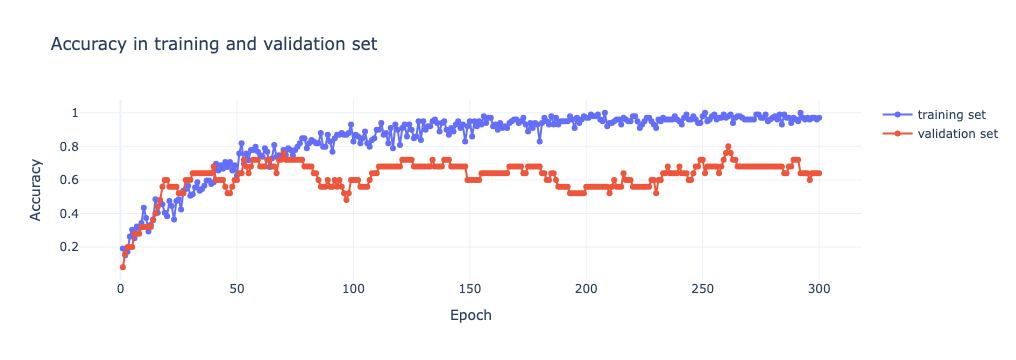

In [16]:
import plotly.graph_objects as go

epoch = np.arange(300) + 1

fig = go.Figure()

# Add traces
fig.add_trace(go.Scatter(x=epoch, y=fit.history['accuracy'],
                    mode='lines+markers',
                    name='training set'))
fig.add_trace(go.Scatter(x=epoch, y=fit.history['val_accuracy'],
                    mode='lines+markers',
                    name='validation set'))

fig.update_layout(title="Accuracy in training and validation set",
                  template='plotly_white')

fig.update_xaxes(title_text='Epoch')
fig.update_yaxes(title_text='Accuracy')

fig.show()

#plot(fig, filename = 'acc_eyes.html')
#display(HTML('acc_eyes.html'))

you evaluate it on the `test set`:

In [17]:
score_ann, acc_ann = model.evaluate(X_test, y_test,
                                    batch_size=2)
print('Test score:', score_ann)
print('Test accuracy:', acc_ann)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5005 - loss: 1.7891 
Test score: 1.9560185670852661
Test accuracy: 0.4838709533214569


Amazing, you did, everything is good...or is it?

Your PI is so happy about this fantastic results that now everyone in the lab should run `machine learning analyses`. 

Thus you are ordered to give everyone on the lab your `analysis script` and a few colleagues try out immediately using the exact same `version` of the `script` and `data`. (I actually asked `6` real people to run it.) 

However, all of them get different results... 

for the `random forest`:

`Accuracy`: 0.52, 0.53, 0.55, 0.58, 0.55     
`MAE`: 1.11, 1.10, 1.12, 1.05, 1.04   

and the `deep learning analyses`, i.e. the `ANN`:

`Test score`: 1.55, 1.44, 1.65, 1.54, 0.83    
`Test accuracy`: 0.55, 0.45, 0.55, 0.55, 0.74

Shocked you rerun your old analyses and it gets worse: your results also differ from the previous run. 

In [18]:
print('previous Accuracy = {}, previous MAE = {}, previous Chance = {}'.format(np.round(np.mean(acc_rf), 3), 
                                                                               np.round(np.mean(-mae_rf), 3), 
                                                                               np.round(1/len(labels.unique()), 3)))

acc = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=10)
mae = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=10, 
                      scoring='neg_mean_absolute_error')

print('Accuracy = {}, MAE = {}, Chance = {}'.format(np.round(np.mean(acc), 3), 
                                                    np.round(np.mean(-mae), 3), 
                                                    np.round(1/len(labels.unique()), 3)))

previous Accuracy = 0.529, previous MAE = 1.055, previous Chance = 0.167
Accuracy = 0.542, MAE = 1.007, Chance = 0.167


In [19]:
# score, acc = model.evaluate(X_test, y_test,
#                             batch_size=2)
print('previous Test score:', score_ann)
print('previous Test accuracy:', acc_ann)

fit = model.fit(X_train, y_train, epochs=300, batch_size=20, validation_split=0.2, verbose=0)

score, acc = model.evaluate(X_test, y_test,
                            batch_size=2)
print('Test score:', score)
print('Test accuracy:', acc)

previous Test score: 1.9560185670852661
previous Test accuracy: 0.4838709533214569
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5308 - loss: 2.4836 
Test score: 2.6159985065460205
Test accuracy: 0.5161290168762207


What is going on...

<img align="center"  src="https://c.tenor.com/oKay8GcV660AAAAC/ted-dancon-evil-laugh.gif" alt="logo" title="Twitter" width="300"/> 
<small><small><small><small><small> via https://c.tenor.com/oKay8GcV660AAAAC/ted-dancon-evil-laugh.gif </small></small></small></small></small>

The inconvenient truth is: as every other analyses you might run within the field of neuroimaging (or other any research field), there is an substantial amount of factors that contribute to the reproducibility of your `machine learning analyses`. Even more so, a lot of the problems are actually elevated due to the complex nature of the `analyses`.

But why care about `reproducibility in machine learning` at all and how can some of the underlying problems be addressed? Let's have a look...

# Why care about `reproducibility` in `machine learning`?

We all know the `reproducibility crisis` in `neuroimaging`...

<img align="center"  src="graphics/reproducibility_imaging.png" alt="logo" title="Twitter" width="700"/>

but we also know that `neuroimaging` is by far no exception to the rule as many other, basically all, research fields have comparable problems. 

This also includes `machine learning`...

<img align="center"  src="graphics/reproducibility_ml.png" alt="logo" title="Twitter" width="700"/>

<small><small> adapted from [Martina Vilas](https://doi.org/10.5281/zenodo.4740053)</small></small>

Besides obviously being a major shortcoming as indicated by this quote from `Popper (The Logic of Scientific Discovery)`,

*`Non-reproducible single occurrences are of no significance to science.`*

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

what are crucial aspects when talking about `reproducibility` in `machine learning` (with a focus on `neuroimaging`)?


<img align="center"  src="https://github.com/suneeta-mall/suneeta-mall.github.io/blob/main/docs/resources/xkcd_1838.png?raw=true" alt="logo" title="Twitter" width="300"/>


<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/talks/KubeCon_US_2019)</small></small>

### Understanding, Explaining, Debugging, and Reverse Engineering


- reproducibility helps with `understanding`, `explaining`, and `debugging` & is crucial to `reverse engineering`


Why is this important?

- `machine learning` is very difficult to `understand`, `explain` and `debug`
-  unreproducible outcomes makes it increasingly harder
- if outcomes are unreproducible & we don't understand what's going in the first place how can we reverse engineer anything?

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

Our example:

- we want to know why our `model` provided us with the obtained `accuracy`
- we want to know what our `model` "learned" from our data
- we want to know if certain `features` are more important than others

Our problem(s):

- we get a different `accuracy` every time we run our `model`
- we can't be sure what our `model` learned from the data
- we can't be sure that certain `features` are more important than others

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

### Correctness 

- reproducibility helps with correctness via understanding and debugging  

Why is this important?

- we want to be sure that the results/effects we observe are actually there or only a fluke 
- important for knowledge generation and advancement in science
- more and more researchers utilize `machine learning` to make `predictions` about `humans` (e.g. `group clustering`, `treatment/therapy plans`, `disease propagation`, etc.) and `unreproducible model predictions` can lead to devastating errors 

Our example:

- we want to be sure that our `model` actually "learned" a way to `reproducibly predict` the `age` of `participants` from their `resting state connectome`

Our problem(s):

- we can't be sure that our `model` actually "learned" in a `reproducible` manner as the outcome varies
- we can't "trust" our `model`

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

### Credibility

- easily `reproducible` (`machine learning`) results are more `credible`

Why is this important?

- we want `FAIR`, `verifiable`, `reliable`, `unbiased` & `ethical` `analyses` and `results`  
- in the near future a lot of very important decisions that will impact lives will depend on `results` from `machine learning analyses` 
- we already saw stunning examples of how easily things go tremendously wrong

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

Our example:

- we want to rely on our result that `age` can be predict from `resting state connectomes` in a `verifiable` and `unbiased` way that is `ethical` and `FAIR`

Our problem(s):

- none of these requirements are fulfilled if our results are not reproducible

### Extensibility

- `reproducibility` helps with `extensibility` of successive steps in a `machine learning analyses`  

Why is this important?

- a given part of a `machine learning analyses` (e.g. `feature engineering`, `layers` of an `ANN`, etc.) need to be `reproducible` so that the respective `analyses` (or pipeline) can be extended
- if results are not `reproducible` subsequent steps like different `post-processing` options and `augmentation` are not feasible/possible

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

Our example:

- we want to extract `features` important for the `prediction` of `age` from the `model`
- we want to `augment` our `model` with new `features` from a different modality (e.g. `DTI`, `behavior`, etc.)

Our problem(s):

- we can't be sure that the importance we extract for the `features` is actually reliable
- we can't `augment` our `model` because it's current state produces `unreproducible` results

### Data harvesting

- `reproducibility` helps with `model training` through `data generation`

Why is this important?

- any type of `machine learning analyses` needs tremendous amounts of `data` to be `trained`, `evaluated` and `tested` on
- due to lack of `data sharing` practices and `standardization`, as well as `quality control` there's actually not enough `data` for most planned (or even conducted) `analyses`
- this is especially true for certain types of `data` (e.g. `disorders`/`disease` with a low prevalence and/or broad spectra)
- `generation of synthetic data` via `machine learning` (e.g. `GAN`s) offers amazing possibilities to address this problem
- for this to work out/make sense, the outcomes, i.e. `synthetic data`, of the `model` need to be `reproducible`

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

Our example:

- if we want to `generate` more `data` based on the one we have (e.g. all `data`, important `features`, etc.), the `generation` of this `data` should be `reproducible`
- if we want to use aspects of the `data` for `synthesizing`, the `derivation` of this `data` should be `reproducible`   

Our problem(s):

- the `model performance`, thus also `derivation` of `data` is not `reproducible` 

At this point you might think:

<img align="center"  src="https://c.tenor.com/LOuJtZ-WL3kAAAAC/holy-forking-shirt-shocked.gif" alt="logo" title="Twitter" width="500"/>


<small><small><small><small> via https://c.tenor.com/LOuJtZ-WL3kAAAAC/holy-forking-shirt-shocked.gif</small></small></small></small>

and you would be right: there are so many things to consider and that can go wrong. 

However, we shouldn't give up quite yet and instead have a look at the underlying problems and how we can address them!

# Challenges in `reproducible machine learning`

Here's another inconvenient truth: every single aspect involved in a `machine learning analyses` creates `variability` and thus entails a major hurdle towards achieving `reproducibility`. 

This not only entails the `computational infrastructure` one is working with but also the `data` as well as common practices during the application of these `analyses`.  

<img align="center"  src="https://suneeta-mall.github.io/resources/reproducible-challenge.jpeg" alt="logo" title="Twitter" width="1000"/>


<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/talks/KubeCon_US_2019)</small></small>

### Hardware

- `machine learning` algorithms require intensive computation and thus can take a very long time to run
- specialized hardware to address this via e.g., `parallelism` & `multiple processing units` (`CPU`), `graphics processing units` (`GPU`), `tensor processing units` (`TPU`), etc.

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

- while very helpful, this introduces problems concerning `reproducibility` based on the underlying `floating-point computations` and appears independent of the `hardware`
- `parallelism` on `CPU`, both `intra-ops` & `inter-ops` (within operation/across multiple operations) can produce different outcomes when run repeatedly 
- `stream multiprocessing` (`SEM`) units in `GPU`s, i.e. `asynchronous computation`, can lead to variable outcomes during repeated runs
- changing the respective `architectures` can also change `model outcomes`

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

### Software

- most commonly used `frameworks` for `machine learning analyses` actually **don't guarantee** 100% `reproducibility`, including `cudnn`, `pytorch` and `tensorflow`
- there's always the danger of `bugs` which can be hard to find based on high-level `API`s

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

- every `computation` requires a complex stack of `software` that quite often interacts and has cross-dependencies
    - `operating system`, `drivers`, `python`, `python packages`, etc.
    - versions of all of the above
    
<img align="center"  src="graphics/computing_environments.png" alt="logo" title="Twitter" width="800"/>    

- `numerical errors & instabilities` of the `software`, e.g. talking about `local minima/maxima` & `floating-point precision again` 
    - `errors` may lead unstable `functions` towards distinct `local minima`
    
    
<img align="center"  src="https://ds055uzetaobb.cloudfront.net/brioche/uploads/JrWaEJKfSc-local-minima.png?width=1200" alt="logo" title="Twitter" width="400"/>    

  
<small><small><small> via https://brilliant.org/wiki/extrema/</small></small></small>

In [20]:
print(sum([0.001 for _ in range(1000)]))

1.0000000000000007


### Algorithm

- the characteristics of quite a few `machine learning algorithms` introduce further problems
- the expectation of `randomness` can lead to `unreproducible` outcomes
- complexity of `computation` can lead to `non-deterministic` results

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

### Practices/Process

- entailing aspects of both previous points, `software` and `algorithm`, `practices` and `processes` in `machine learning` also heavily influence the `reproducibility` of results
- most prominently this entails `randomness`, because it's basically everywhere

- `random initializations`
- `random augmentations`
- `random noise introduction`
- `data shuffles`
- etc.

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

Here's just a brief example concerning `data shuffling` in `training sets`: 

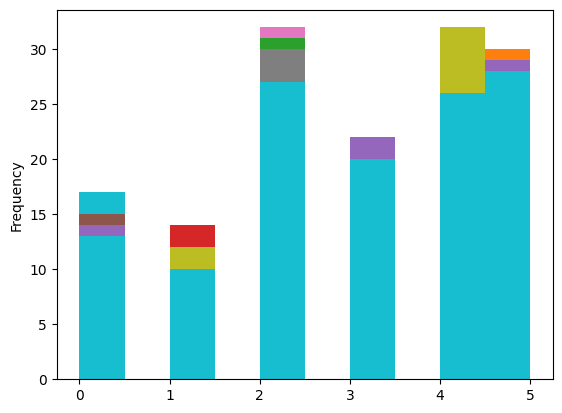

In [21]:
for i in range(100):

    X_train, X_test, y_train, y_test = train_test_split(data, pd.Categorical(labels).codes, test_size=0.2, shuffle=True)
    
    pd.Series(y_train).plot(kind='hist', stacked=True)
    

### Data

- even though commonly ignored: `machine learning analysis` need tremendous amounts of `data`, the buzz word is "`big data`"
- given that `data standardization & management` are still not frequently applied, even in small `datasets`, "`big data`" poses additional major problems  

- when working with any kind of `data`, especially "`big data`" various aspects need to be addressed
    - `data management`
    - `data provenance`
    - `data poisoning`
    - `under-/over-represented data`

<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>

- this concerns basically every aspect of `machine learning analyses`, e.g. `feature engineering`, `augmentation`, etc.

- another important aspect that interacts with all of the above is the limited re-usability of `models`
- only a small subset of `models` is used more than once, which is grounded in two main factors (among others)

- absent sharing of `trained models`
    - `training models` can take a very long time as previously outlined and additionally consume large amounts of resources
    - sharing `trained models` or `weights` thereof is necessary to reduce these costs and further validate the `models` in terms of `reproducibility`, `reliability`, `robustness` and `generalization`

- everything we do with `machine learning` is more or less affected by `concept drift`
    - our `concept` of the world that surrounds us and the things within is constantly changing (e.g. `disease`/ `disorder` subtypes and progressions, etc.)
    - we as `biological agents` need to make `artificial agents` aware of this
    - in `machine learning` this process is referred to as `continual learning`
    
<small><small> adapted from [Suneeta Mall](https://suneeta-mall.github.io/2019/12/21/Reproducible-ml-research-n-industry.html)</small></small>    

At this point you might think:

<img align="center"  src="https://media2.giphy.com/media/cRMGqNpvm9XS2gRcpL/giphy.gif" alt="logo" title="Twitter" width="500"/>


<small><small><small><small> via [GIPHY](https://media2.giphy.com/media/cRMGqNpvm9XS2gRcpL/giphy.gif)</small></small></small></small>

But again: there's something we can do to make it at least slightly better. Thus, let's get to it!

# Pointers to increase `reproducibility` in `machine learning`

- given the outlined challenges, we can now think about how we can address the respective problems
- the good thing is: a lot of the work and efforts done to increase `reproducibility` in `neuroimaging` can also be utilized to increase `reproducibility` in `machine learning`

- this thus also entails tools and resources provided by `ReproNim` and its members, as well as adjacent initiatives

- in more detail we will have a look at the following challenges and respectively helpful aspects

    - `software`: `virtualization` of `computing environments` using [neurodocker]()
    - `algorithm`/`practices`/`processes`: dealing with `randomness`
    - `data`: `standardization` ([BIDS]()), tracking everything ([git]()/[github]() & [datalad]()), sharing

<img align="right" src="https://www.repronim.org/images/logo-square-256.png" alt="logo" title="Twitter" width="100"/>


- unfortunately, `ReproNim` doesn't offer to `hardware` resources yet, so we have to keep that aside for now 

### Software: `virtualization` of `computing environments` using [neurodocker]()

- as mentioned above every `computing environment` is composed of many different aspects
    - `operating system`, `drivers`, `python`, `python packages`
    - different `versions` thereof
    - etc.

Obviously, we can't send around our machines via post.

So what can we do to address this?

We can make use of `virtualization technologies` that aim to:

- isolate the computing environment
- provide a mechanism to encapsulate environments in a self-contained unit that can run anywhere
    - reconstructing computing environments
    - sharing computing environments 


<img align="center"  src="graphics/computing_environments_share.png" alt="logo" title="Twitter" width="800"/>        

Overall, there are several `types` of `virtualization` that are situated across different `levels`:

- `pure python virtualization` using [venv]() & [conda]()

- `software containers` like [docker]() & [singularity]()

- `virtual machines` like [Virtualbox]() & [VMware]()

<img align="right"  src="graphics/computing_environments_levels.png" alt="logo" title="Twitter" width="400"/>        

As discussed before, `machine learning analyses` need a lot of `computational resources` to run in a feasible amount of time. Thus, usually we want to make use of `HPC`s which excludes `virtual machines` from the suitable options, as their handling, management and resource allocation don't really scale. 

In contrast, both `python virtualization` and `software containers` work reasonably well on `HPC`s (regarding utilization, management and resource allocation). 

The creation, combination and management of both is made incredibly easy and even `reproducible` via [neurodocker]()!

- a `containerized software` aimed at the `reproducible generation` of other `containerized software`
- supports `python virtualization` using `conda`, `docker` and `singularity`, as well as `neuroimaging-specific software`


You might wonder: "why do we need both"?

- `python virtualization` does not account for often required `libraries` and `binaries` on other levels (beyond `python`)
- for this we need the subsequent level of `virtualization`, i.e. `software containers` that share the `host system's kernel` and (can) include everything from `libraries` and `binaries` upwards

In order to create a `software container`, here `docker`, that entails a `python environment` with all `packages` in the `version`s that were used to run the initial `analyses`, we only need to do the following:

In [ ]:
%%bash 

docker run kaczmarj/neurodocker:0.6.0 generate docker --base=ubuntu:18.04 \
--pkg-manager=apt \
--install git nano unzip \
--miniconda \
    version=latest \
    create_env='repronim_ml' \
    activate=true \
    conda_install="python=3.11.0 numpy=1.26.4 pandas=2.3.0 scikit-learn=1.7.0 seaborn=0.13.2" \
    pip_install="tensorflow==2.16.2 datalad[full]==1.2.0" \
--add-to-entrypoint "source activate repronim_ml" \
--entrypoint "/neurodocker/startup.sh  python" > Dockerfile

docker build -t peerherholz/repronim_ml:0.2 .

As this takes a while, we can also just grab the generated container from `dockerhub`:

In [22]:
%%bash 

docker pull peerherholz/repronim_ml:0.2

0.2: Pulling from peerherholz/repronim_ml
Digest: sha256:6fc095cd8c0904383bdc9d76610d6c366010fa7f7db27a1ea14b3babe10912f2
Status: Image is up to date for peerherholz/repronim_ml:0.2
docker.io/peerherholz/repronim_ml:0.2


With that, we already have our `software container` ready to go and can run our `machine learning analyses` in it: 

In [23]:
%%bash

docker images

REPOSITORY                TAG       IMAGE ID       CREATED       SIZE
peerherholz/repronim_ml   0.2       35867f73b6df   4 days ago    3.51GB
kaczmarj/neurodocker      0.6.0     7029883696dd   5 years ago   79.3MB


Here, the `software container` is set up in a way that it automatically executes/runs `python`, specifically the `version` of the `conda environment` we created. Thus, we can simply provide a `python script` as an `input`.

In [24]:
%%bash

docker run -i --rm -v /Users/peerherholz/google_drive/GitHub/repronim_ML/:/data peerherholz/repronim_ml:0.2 /data/code/ml_reproducibility_data.py

2025-06-17 09:50:22.628547: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 09:50:22.809540: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 09:50:23.030043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-17 09:50:23.264731: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-17 09:50:23.266191: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-17 09:50:23.587105: I tensorflow/core/platform/cpu_feature_guard.cc:

Epoch 1/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.1682 - loss: 3.1353 - val_accuracy: 0.1600 - val_loss: 1.7578
Epoch 2/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2005 - loss: 2.9439 - val_accuracy: 0.2000 - val_loss: 1.7421
Epoch 3/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1965 - loss: 2.7430 - val_accuracy: 0.2000 - val_loss: 1.7247
Epoch 4/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2090 - loss: 2.4735 - val_accuracy: 0.2400 - val_loss: 1.7127
Epoch 5/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3182 - loss: 1.9886 - val_accuracy: 0.2400 - val_loss: 1.7089
Epoch 6/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2426 - loss: 2.4080 - val_accuracy: 0.2400 - val_loss: 1.7039
Epoch 7/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3384 - loss: 1.9718 - val_accuracy: 0.3200 - val_loss: 1.6989
Epoch 8/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3158 - loss: 1.8423 - val_accuracy: 0.2800 - 

Results - random forest
Accuracy = 0.548, MAE = 0.955, Chance = 0.167
Results - ANN
Test score: 1.1399775743484497
Test accuracy: 0.7419354915618896
/data/code


Epoch 60/300
5/5 [==============================] - 0s 26ms/step - loss: 0.6382 - accuracy: 0.7778 - val_loss: 1.4754 - val_accuracy: 0.4800
Epoch 61/300
5/5 [==============================] - 0s 24ms/step - loss: 0.6680 - accuracy: 0.7677 - val_loss: 1.4642 - val_accuracy: 0.4800
Epoch 62/300
5/5 [==============================] - 0s 21ms/step - loss: 0.6347 - accuracy: 0.7879 - val_loss: 1.4632 - val_accuracy: 0.4400
Epoch 63/300
5/5 [==============================] - 0s 22ms/step - loss: 0.6569 - accuracy: 0.7879 - val_loss: 1.4635 - val_accuracy: 0.4400
Epoch 64/300
5/5 [==============================] - 0s 22ms/step - loss: 0.6712 - accuracy: 0.7677 - val_loss: 1.4728 - val_accuracy: 0.4400
Epoch 65/300
5/5 [==============================] - 0s 26ms/step - loss: 0.6282 - accuracy: 0.7677 - val_loss: 1.4765 - val_accuracy: 0.4800
Epoch 66/300
5/5 [==============================] - 0s 21ms/step - loss: 0.5692 - accuracy: 0.8182 - val_loss: 1.4668 - val_accuracy: 0.4800
Epoch 67/300


Epoch 118/300
5/5 [==============================] - 0s 33ms/step - loss: 0.3176 - accuracy: 0.9091 - val_loss: 1.7320 - val_accuracy: 0.4800
Epoch 119/300
5/5 [==============================] - 0s 24ms/step - loss: 0.4660 - accuracy: 0.8182 - val_loss: 1.7235 - val_accuracy: 0.4800
Epoch 120/300
5/5 [==============================] - 0s 20ms/step - loss: 0.3061 - accuracy: 0.9293 - val_loss: 1.6986 - val_accuracy: 0.5200
Epoch 121/300
5/5 [==============================] - 0s 23ms/step - loss: 0.2786 - accuracy: 0.9293 - val_loss: 1.6593 - val_accuracy: 0.5200
Epoch 122/300
5/5 [==============================] - 0s 24ms/step - loss: 0.3667 - accuracy: 0.8889 - val_loss: 1.6166 - val_accuracy: 0.5200
Epoch 123/300
5/5 [==============================] - 0s 26ms/step - loss: 0.2835 - accuracy: 0.9091 - val_loss: 1.5841 - val_accuracy: 0.5200
Epoch 124/300
5/5 [==============================] - 3s 746ms/step - loss: 0.3190 - accuracy: 0.9091 - val_loss: 1.5669 - val_accuracy: 0.5200
Epoch

Epoch 176/300
5/5 [==============================] - 0s 26ms/step - loss: 0.1927 - accuracy: 0.9798 - val_loss: 1.8254 - val_accuracy: 0.5200
Epoch 177/300
5/5 [==============================] - 0s 36ms/step - loss: 0.1440 - accuracy: 0.9899 - val_loss: 1.8404 - val_accuracy: 0.5200
Epoch 178/300
5/5 [==============================] - 0s 32ms/step - loss: 0.1524 - accuracy: 0.9596 - val_loss: 1.8214 - val_accuracy: 0.5200
Epoch 179/300
5/5 [==============================] - 0s 41ms/step - loss: 0.2181 - accuracy: 0.9495 - val_loss: 1.8011 - val_accuracy: 0.5200
Epoch 180/300
5/5 [==============================] - 0s 39ms/step - loss: 0.2524 - accuracy: 0.9394 - val_loss: 1.7382 - val_accuracy: 0.5600
Epoch 181/300
5/5 [==============================] - 0s 29ms/step - loss: 0.1701 - accuracy: 0.9495 - val_loss: 1.6697 - val_accuracy: 0.5600
Epoch 182/300
5/5 [==============================] - 0s 20ms/step - loss: 0.1604 - accuracy: 0.9697 - val_loss: 1.6532 - val_accuracy: 0.5600
Epoch 

Epoch 234/300
5/5 [==============================] - 0s 99ms/step - loss: 0.1262 - accuracy: 0.9697 - val_loss: 1.5515 - val_accuracy: 0.5600
Epoch 235/300
5/5 [==============================] - 0s 47ms/step - loss: 0.1194 - accuracy: 0.9596 - val_loss: 1.5623 - val_accuracy: 0.5200
Epoch 236/300
5/5 [==============================] - 0s 26ms/step - loss: 0.1293 - accuracy: 0.9798 - val_loss: 1.5481 - val_accuracy: 0.5200
Epoch 237/300
5/5 [==============================] - 0s 20ms/step - loss: 0.2025 - accuracy: 0.9394 - val_loss: 1.5346 - val_accuracy: 0.5200
Epoch 238/300
5/5 [==============================] - 0s 20ms/step - loss: 0.1270 - accuracy: 0.9798 - val_loss: 1.5373 - val_accuracy: 0.5200
Epoch 239/300
5/5 [==============================] - 0s 20ms/step - loss: 0.0996 - accuracy: 0.9899 - val_loss: 1.5452 - val_accuracy: 0.5200
Epoch 240/300
5/5 [==============================] - 0s 44ms/step - loss: 0.1174 - accuracy: 0.9798 - val_loss: 1.5536 - val_accuracy: 0.4800
Epoch 

Epoch 292/300
5/5 [==============================] - 0s 21ms/step - loss: 0.0774 - accuracy: 0.9899 - val_loss: 2.1721 - val_accuracy: 0.5200
Epoch 293/300
5/5 [==============================] - 0s 16ms/step - loss: 0.0694 - accuracy: 0.9899 - val_loss: 2.1385 - val_accuracy: 0.5200
Epoch 294/300
5/5 [==============================] - 0s 15ms/step - loss: 0.1353 - accuracy: 0.9596 - val_loss: 2.1117 - val_accuracy: 0.5200
Epoch 295/300
5/5 [==============================] - 0s 16ms/step - loss: 0.0913 - accuracy: 0.9899 - val_loss: 2.0809 - val_accuracy: 0.5200
Epoch 296/300
5/5 [==============================] - 0s 15ms/step - loss: 0.1546 - accuracy: 0.9394 - val_loss: 2.1287 - val_accuracy: 0.5200
Epoch 297/300
5/5 [==============================] - 0s 15ms/step - loss: 0.0776 - accuracy: 0.9798 - val_loss: 2.1958 - val_accuracy: 0.5600
Epoch 298/300
5/5 [==============================] - 0s 15ms/step - loss: 0.1065 - accuracy: 0.9798 - val_loss: 2.2366 - val_accuracy: 0.5600
Epoch 

Fantastic, now we can run and further test our `machine learning analyses` in a dedicated `computing environment` that is isolated and shareable! 

Now that a large portion of the `software dependencies` are addressed, we can continue with the next part: `algorithm`/`practices`/`processes`!

### `algorithm`/`practices`/`processes` : dealing with randomness

- as discussed above, `randomness` is basically everywhere in the world of `machine learning`
- while often expected or even required, if not done "right" it can/will lead to `unreproducible` results

So what can we do? 

Simply put, we need to `seed` the `randomness` in our `machine learning analyses`!

- all `software` has the option to set the `seed` for `randomness`, one way or another
- where and how the `seed` can be set unfortunately varies between `software packages`
- often, the `seed` needs to be set at different instances

For example, in our `machine learning analyses` using a `random forest`, we didn't `seed` `randomness` so far, resulting in different outcomes at every run because e.g. `training` and `test set splits` would vary: 

In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold()

pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier()
)

for i in range(10):

    acc = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=cv)
    mae = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=cv, 
                      scoring='neg_mean_absolute_error')

    print('Accuracy run {} = {}, MAE run {} = {}, Chance run {} = {}'.format(i, np.round(np.mean(acc), 3), 
                                                        i, np.round(np.mean(-mae), 3), 
                                                        i, np.round(1/len(labels.unique()), 3)))

Accuracy run 0 = 0.535, MAE run 0 = 1.032, Chance run 0 = 0.167
Accuracy run 1 = 0.568, MAE run 1 = 1.142, Chance run 1 = 0.167
Accuracy run 2 = 0.51, MAE run 2 = 1.032, Chance run 2 = 0.167
Accuracy run 3 = 0.535, MAE run 3 = 1.097, Chance run 3 = 0.167
Accuracy run 4 = 0.49, MAE run 4 = 1.026, Chance run 4 = 0.167
Accuracy run 5 = 0.535, MAE run 5 = 0.961, Chance run 5 = 0.167
Accuracy run 6 = 0.529, MAE run 6 = 1.129, Chance run 6 = 0.167
Accuracy run 7 = 0.568, MAE run 7 = 1.09, Chance run 7 = 0.167
Accuracy run 8 = 0.581, MAE run 8 = 1.11, Chance run 8 = 0.167
Accuracy run 9 = 0.568, MAE run 9 = 1.006, Chance run 9 = 0.167


Using the `random_state` `argument` in all `functions`/`classes` that deal with `randomness` to set the `seed`, results in `reproducible` outcomes at every run: 

In [26]:
cv = StratifiedKFold(random_state=42, shuffle=True)

pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

for i in range(10):

    acc = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=cv)
    mae = cross_val_score(pipe, data, pd.Categorical(labels).codes, cv=cv, 
                      scoring='neg_mean_absolute_error')

    print('Accuracy run {} = {}, MAE run {} = {}, Chance run {} = {}'.format(i, np.round(np.mean(acc), 3), 
                                                        i, np.round(np.mean(-mae), 3), 
                                                        i, np.round(1/len(labels.unique()), 3)))

Accuracy run 0 = 0.548, MAE run 0 = 0.955, Chance run 0 = 0.167
Accuracy run 1 = 0.548, MAE run 1 = 0.955, Chance run 1 = 0.167
Accuracy run 2 = 0.548, MAE run 2 = 0.955, Chance run 2 = 0.167
Accuracy run 3 = 0.548, MAE run 3 = 0.955, Chance run 3 = 0.167
Accuracy run 4 = 0.548, MAE run 4 = 0.955, Chance run 4 = 0.167
Accuracy run 5 = 0.548, MAE run 5 = 0.955, Chance run 5 = 0.167
Accuracy run 6 = 0.548, MAE run 6 = 0.955, Chance run 6 = 0.167
Accuracy run 7 = 0.548, MAE run 7 = 0.955, Chance run 7 = 0.167
Accuracy run 8 = 0.548, MAE run 8 = 0.955, Chance run 8 = 0.167
Accuracy run 9 = 0.548, MAE run 9 = 0.955, Chance run 9 = 0.167


Regarding our `ANN`, we would need to set the `random_state` `argument` for the `train_test_split` `function` to create `training` and `test sets` in a `reproducible` manner:

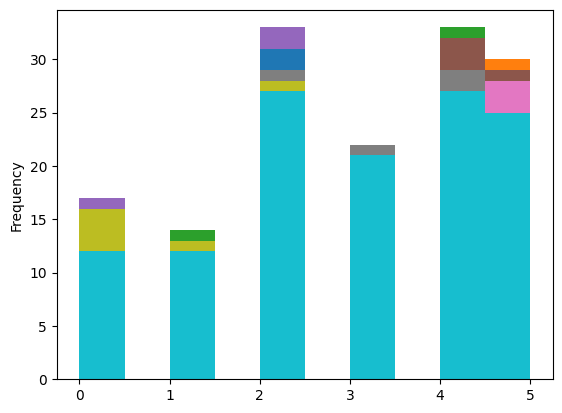

In [27]:
for i in range(100):

    X_train, X_test, y_train, y_test = train_test_split(data, pd.Categorical(labels).codes, test_size=0.2, shuffle=True)
    
    pd.Series(y_train).plot(kind='hist', stacked=True)

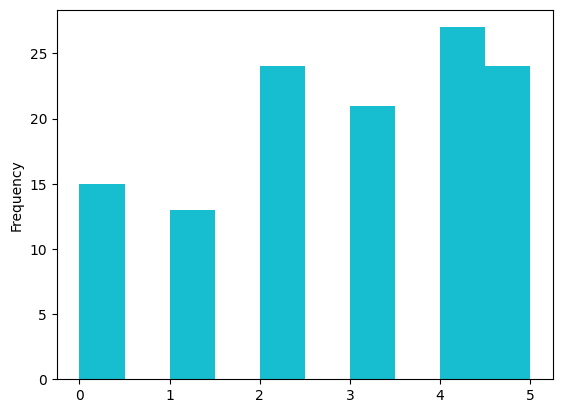

In [28]:
for i in range(100):

    X_train, X_test, y_train, y_test = train_test_split(data, pd.Categorical(labels).codes, 
                                                        test_size=0.2, shuffle=True,
                                                        random_state=42)
    
    pd.Series(y_train).plot(kind='hist', stacked=True)

Additionally, we would need to set the `seed` across various parts of our `computational environment`. Without that, we get different results at every run:

In [29]:
for i in range(10):

    model = keras.Sequential()

    model.add(layers.Input(shape=data[1].shape))
    model.add(layers.Dense(100, activation="relu", kernel_initializer='he_normal', bias_initializer='zeros'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(50, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(25, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(len(labels.unique()), activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam', 
                  metrics=['accuracy'])

    fit = model.fit(X_train, y_train, epochs=30, batch_size=20, validation_split=0.2, verbose=0)

    score, acc = model.evaluate(X_test, y_test,
                                batch_size=2, verbose=0)
    print('Test score run {}: {} , Test accuracy run {}: {}'.format(i, score, i, acc))

Test score run 0: 1.2065298557281494 , Test accuracy run 0: 0.6129032373428345
Test score run 1: 1.299221158027649 , Test accuracy run 1: 0.5161290168762207
Test score run 2: 1.126314640045166 , Test accuracy run 2: 0.6129032373428345
Test score run 3: 1.611088514328003 , Test accuracy run 3: 0.3870967626571655
Test score run 4: 1.2121350765228271 , Test accuracy run 4: 0.6129032373428345
Test score run 5: 1.1756813526153564 , Test accuracy run 5: 0.5806451439857483
Test score run 6: 1.3319497108459473 , Test accuracy run 6: 0.35483869910240173
Test score run 7: 1.2700525522232056 , Test accuracy run 7: 0.6129032373428345
Test score run 8: 1.2562886476516724 , Test accuracy run 8: 0.6774193644523621
Test score run 9: 1.2847849130630493 , Test accuracy run 9: 0.6129032373428345


After setting the `seed`, for example the `general random seeds` and the `tensorflow seed`, we get the same output every run: 

In [30]:
import os, random

for i in range(10):

    # Set all seeds at the beginning, before the loop
    os.environ['PYTHONHASHSEED'] = str(42)
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)
    
    model = keras.Sequential()
    model.add(layers.Input(shape=data[1].shape))
    model.add(layers.Dense(100, activation="relu", kernel_initializer='he_normal', bias_initializer='zeros'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(50, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(25, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(labels.unique()), activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam', 
                  metrics=['accuracy'])
    
    fit = model.fit(X_train, y_train, epochs=30, batch_size=20, validation_split=0.2, verbose=0)
    score, acc = model.evaluate(X_test, y_test, batch_size=2, verbose=0)
    
    print('Test score run {}: {} , Test accuracy run {}: {}'.format(i, score, i, acc))

Test score run 0: 1.2624965906143188 , Test accuracy run 0: 0.5806451439857483
Test score run 1: 1.2624965906143188 , Test accuracy run 1: 0.5806451439857483
Test score run 2: 1.2624965906143188 , Test accuracy run 2: 0.5806451439857483
Test score run 3: 1.2624965906143188 , Test accuracy run 3: 0.5806451439857483
Test score run 4: 1.2624965906143188 , Test accuracy run 4: 0.5806451439857483
Test score run 5: 1.2624965906143188 , Test accuracy run 5: 0.5806451439857483
Test score run 6: 1.2624965906143188 , Test accuracy run 6: 0.5806451439857483
Test score run 7: 1.2624965906143188 , Test accuracy run 7: 0.5806451439857483
Test score run 8: 1.2624965906143188 , Test accuracy run 8: 0.5806451439857483
Test score run 9: 1.2624965906143188 , Test accuracy run 9: 0.5806451439857483


Please note, that this appears to be sufficient for our minimal example but more realistic `ANN`s would potentially require way more steps to achieve `reproducibility`, including:

- setting `inter`/`intra op parallelism` 

In [31]:
from tensorflow.python.eager import context

context._context = None
context._create_context()

tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

- address `determinism` via `os` and/or utilizing `packages`, like [Framework determinism](https://nvidia.github.io/framework-determinism/) but starting with `tensorflow` version `2.8`, you can set it directly:

In [32]:
# os.environ['TF_DETERMINISTIC_OPS'] = '1'

# from tfdeterminism import patch
# patch()

tf.config.experimental.enable_op_determinism()


The respective solution will depend on your `computational environment`, `model architecture`, `data`, etc. and might sometimes not even exist (at least within a reasonable implementation).

This ongoing concern itself became a new field of study, with fascinating and very helpful outputs, e.g.

<img align="center"  src="graphics/ML_variability.png" alt="logo" title="Twitter" width="700"/>        

[Bouthillier et al. (2021): Accounting for variability in machine learning benchmarks](https://proceedings.mlsys.org/paper/2021/file/cfecdb276f634854f3ef915e2e980c31-Paper.pdf)

<small><small> adapted from [Martina Vilas](https://doi.org/10.5281/zenodo.4740053)</small></small>

### `data`: `standardization` ([BIDS]()), tracking everything ([git]()/[github]() & [datalad]()), sharing

- as mentioned before, `data` is crucial & thus everything adjacent to it is crucial as well
- `standardization` of `data` & `models` to facilitate `management`, `QC` and `FAIR`-ness
- keeping track of everything using `version control`
- `sharing` `data` & `models` to maximize `reproducibility` & `FAIR`-ness, as well as to reduce `computational effort`

#### standardization of `data` & `models`

- `standardizing` `data` & `models`, as well as their description is tremendously helpful & important concerning `reproducibility` and other aspects, independent of the `data` at hand
- `big data` however profits even more from this process as the combination of `human`/`machine` readability and `meta-data` allows to efficiently handle `data management`, `evaluation`, `QC`, `augmentation`, etc.

One of the best options to tackle this is of course the [Brain Imaging Data Structure]() or `BIDS`:

<img align="center"  src="graphics/BIDS.png" alt="logo" title="Twitter" width="700"/>        

<img align="center"  src="graphics/BIDS_example.png" alt="logo" title="Twitter" width="1000"/>        

<img align="center"  src="graphics/BIDS_info.png" alt="logo" title="Twitter" width="1000"/>        

<img align="center"  src="graphics/BIDS_models.png" alt="logo" title="Twitter" width="700"/>        

### Keeping track of everything using `version control`

- as mentioned before: `machine learning analyses` tend to be very complex and thus a lot can happen along the way
- the `analysis code`, as well as `data input` and `output` might change frequently
- without keeping track of these frequent changes, `reproducibility` is basically not possible

One commonly know tool to address this is `version control`, which itself can take different forms, depending on the precise `data` at hand.

The most utilized & well known `software` is [git](), with quite a few `software` `packages` & `platforms` building upon it. For example, [GitHub]() & [datalad]().

<img align="center"  src="graphics/version_control.png" alt="logo" title="Twitter" width="400"/>        

Placing everything one does under `version control` via these `tools` & `resources` can help a great deal to achieve `reproducibility`, as the respective aspects, e.g. `code` & `data` are constantly `monitored` and changes `tracked`. 

For example, starting with our `machine learning analyses python script`, what if we apply certain changes and the outcomes vary as a result of it? Using `version control`, it's "easy" to evaluate what happened and restore previous versions!

We actually adapted our `python script` so that the `analyses` are more `reproducible`. With `git`, we can see that:

<img align="center"  src="graphics/version_control_script.png" alt="logo" title="Twitter" width="1000"/>        

While `code version control` using `git` and `GitHub` is fortunately more and more common, `version control` of other forms of `data`, e.g. `datasets` is not. 

For example, what happens when we run multiple `machine learning analyses` on the same `dataset` that yield different outcomes? How do we keep track of that?

One up and coming `tool` that allows to "easily" `track` changes in all kinds of `data`, is `DataLad`.

With it, one can create `version controlled` `datasets` of basically any form and monitor every change that appears along the way, including `input`s and `output`s, `files` in general, utilized `software`, etc. . 

Applied to our `machine learning analyses`, this could look as follows: 

We create a new `dataset`:

In [45]:
%%bash
datalad create repronim_ml_showcase

create(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase (dataset)


And `download` the `data`, `installing` it as `dataset`:

In [46]:
%%bash 
cd repronim_ml_showcase
datalad download-url \
  --archive \
  --message "Download dataset" \
  'https://www.dropbox.com/s/v48f8pjfw4u2bxi/MAIN_BASC064_subsamp_features.npz?dl=1'

[INFO] Downloading 'https://www.dropbox.com/s/v48f8pjfw4u2bxi/MAIN_BASC064_subsamp_features.npz?dl=1' into '/Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/' 
[INFO] Adding content of the archive /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/MAIN_BASC064_subsamp_features.npz into annex AnnexRepo(/Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase) 
[INFO] Initializing special remote datalad-archives 
[INFO] Extracting archive 
[INFO] Finished adding /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/MAIN_BASC064_subsamp_features.npz: Files processed: 1, +annex: 1 
[INFO] Finished extraction 


download_url(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/MAIN_BASC064_subsamp_features.npz (file)
add(ok): MAIN_BASC064_subsamp_features.npz (file)
save(ok): . (dataset)
add-archive-content(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase (dataset)
action summary:
  add (ok: 1)
  add-archive-content (ok: 1)
  download_url (ok: 1)
  save (ok: 1)


In [47]:
%%bash 
cd repronim_ml_showcase
datalad download-url \
  --message "Download labels" \
  'https://www.dropbox.com/s/ofsqdcukyde4lke/participants.csv?dl=1'

[INFO] Downloading 'https://www.dropbox.com/s/ofsqdcukyde4lke/participants.csv?dl=1' into '/Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/' 


download_url(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/participants.csv (file)
add(ok): participants.csv (file)
save(ok): . (dataset)
action summary:
  add (ok: 1)
  download_url (ok: 1)
  save (ok: 1)


We then can use `DataLad`'s [YODA]() principles to create a directory structure for our project, including folders for `data` and `code`:

In [48]:
%%bash
cd repronim_ml_showcase
datalad create -c text2git -c yoda ml_showcase

[INFO] Running procedure cfg_text2git 
[INFO] == Command start (output follows) ===== 
[INFO] == Command exit (modification check follows) ===== 
[INFO] Running procedure cfg_yoda 
[INFO] == Command start (output follows) ===== 
[INFO] == Command exit (modification check follows) ===== 


run(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase (dataset) [/Users/peerherholz/anaconda3/envs/repron...]
run(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase (dataset) [/Users/peerherholz/anaconda3/envs/repron...]
create(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase (dataset)
action summary:
  create (ok: 1)
  run (ok: 2)


and subsequently `clone` the installed `dataset`s into the `data` folder, indicating that this is our `raw data`:


In [49]:
%%bash
cd repronim_ml_showcase/ml_showcase
mkdir -p data
datalad clone -d . ../ data/raw

[INFO] Attempting a clone into /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase/data/raw 
[INFO] Attempting to clone from ../ to /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase/data/raw 
[INFO] Completed clone attempts for Dataset(/Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase/data/raw) 


install(ok): data/raw (dataset)
add(ok): data/raw (dataset)
add(ok): .gitmodules (file)
save(ok): . (dataset)
add(ok): .gitmodules (file)
save(ok): . (dataset)
action summary:
  add (ok: 3)
  install (ok: 1)
  save (ok: 2)


To make things as `reproducible` as possible, we also add our `software container` from above to the `dataset`, so that the `computational environment` and it's application is also `version control`led:

In [50]:
%%bash
cd repronim_ml_showcase/ml_showcase
datalad containers-add repronim-ml-container --url dhub://peerherholz/repronim_ml:0.2

0.2: Pulling from peerherholz/repronim_ml
Digest: sha256:6fc095cd8c0904383bdc9d76610d6c366010fa7f7db27a1ea14b3babe10912f2
Status: Image is up to date for peerherholz/repronim_ml:0.2
docker.io/peerherholz/repronim_ml:0.2


[INFO] Saved peerherholz/repronim_ml:0.2 to /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase/.datalad/environments/repronim-ml-container/image 


add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/0a38d0bfe80294b873773cbc3acea6946a27f55386fc9330e249fb9835a66ac9 (file)
add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/0e50ef12a510a65beb20b5122fba717d6a41036693327c541b6f94e9c2bf2262 (file)
add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/0ebe55b09a47ee25a918f3dab37487c865e917e44fa4ec1f4cdf9ef5d35bed51 (file)
add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/35867f73b6dfe02ae68121d8b3cf79d057c521d9f6e3a6eca9a679e3d2615947 (file)
add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/41a6e8d17b82379404f6b5d8d57bbb895bb8a33bdf6f3a0158252b6d1e152e31 (file)
add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/4eb5769c3f8c38670f47db5a2f2e465015ca96117427ce3f498c708d1735774a (file)
add(ok): .datalad/environments/repronim-ml-container/image/blobs/sha256/548a79621a426b4eb077c926eabac5a8620c454fb230640253e1b44dc7dd7562

The only thing that's missing is the `python script` that performs the `machine learning analyses`, which can simply be added to the `dataset` as well. 

In [51]:
%%bash
cd repronim_ml_showcase/ml_showcase/
cp ../../code/ml_reproducibility.py code/
datalad save -m "add random forest & ANN script" code/ml_reproducibility.py

add(ok): code/ml_reproducibility.py (file)
save(ok): . (dataset)
action summary:
  add (ok: 1)
  save (ok: 1)


With that, we already have everything in place to run a (fully) `reproducible` `machine learning analysis`, that `track`s the `dataset`s, the `computational environment`, the `code` and also their interaction via monitoring `analyses` `input`s and `output`s:

In [52]:
%%bash
cd repronim_ml_showcase/ml_showcase/
datalad containers-run -n repronim-ml-container \
  -m "First run of ML analyses" \
  --input 'data/raw/' \
  --output 'metrics.json' \
  --output 'random_forest.joblib' \
  --output 'ANN.h5' \
  "code/ml_reproducibility.py"

[INFO] Making sure inputs are available (this may take some time) 
[INFO] == Command start (output follows) ===== 
whoami: cannot find name for user ID 501
2025-06-18 09:33:31.153959: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 09:33:31.513127: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 09:33:31.782859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-18 09:33:32.569327: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-18 09:33:32.569779: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attemp

Epoch 1/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 8s 294ms/step - accuracy: 0.1682 - loss: 3.1353 - val_accuracy: 0.1600 - val_loss: 1.7578
Epoch 2/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.2005 - loss: 2.9439 - val_accuracy: 0.2000 - val_loss: 1.7421
Epoch 3/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1965 - loss: 2.7430 - val_accuracy: 0.2000 - val_loss: 1.7247
Epoch 4/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2090 - loss: 2.4735 - val_accuracy: 0.2400 - val_loss: 1.7127
Epoch 5/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3182 - loss: 1.9886 - val_accuracy: 0.2400 - val_loss: 1.7089
Epoch 6/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2426 - loss: 2.4080 - val_accuracy: 0.2400 - val_loss: 1.7039
Epoch 7/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3384 - loss: 1.9718 - val_accuracy: 0.3200 - val_loss: 1.6989
Epoch 8/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3158 - loss: 1.8423 - val_accuracy: 0.2800 -

Results - random forest
Accuracy = 0.548, MAE = 0.955, Chance = 0.167
Results - ANN
Test score: 1.1399775743484497
Test accuracy: 0.7419354915618896


[INFO] == Command exit (modification check follows) ===== 


get(ok): data/raw/a.npy (file) [from origin...]
get(ok): data/raw/participants.csv (file) [from origin...]
run(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase (dataset) [/Users/peerherholz/anaconda3/envs/repron...]
add(ok): .keras/keras.json (file)
add(ok): ANN.h5 (file)
add(ok): metrics.json (file)
add(ok): random_forest.joblib (file)
save(ok): . (dataset)
action summary:
  add (ok: 4)
  get (notneeded: 3, ok: 2)
  run (ok: 1)
  save (notneeded: 1, ok: 1)


Not only can we obtain `reproducible` results via the combination of `software containers` and `seed`ing:

In [53]:
%%bash
cd repronim_ml_showcase/ml_showcase/
cat metrics.json

{"accuracy": 0.548, "MAE": 0.955, "Chance": 0.167, "Test score": 1.1399775743484497, "Test accuracy": 0.7419354915618896}

but we also get a full `log` of everything that happened in and to our `dataset`. 

In [66]:
%%bash
cd repronim_ml_showcase/ml_showcase/
git log

commit 2b9bfeee8c2ee2fc2d22bd791363105fcd9bd659
Author: Peer Herholz <herholz.peer@gmail.com>
Date:   Wed Jun 18 17:35:31 2025 +0800

    [DATALAD RUNCMD] First run of ML analyses
    
    === Do not change lines below ===
    {
     "chain": [],
     "cmd": "/Users/peerherholz/anaconda3/envs/repronim_ml/bin/python3.1 -m datalad_container.adapters.docker run .datalad/environments/repronim-ml-container/image code/ml_reproducibility.py",
     "dsid": "0d5d4cb4-7dba-4694-aa88-4606ff3be15e",
     "exit": 0,
     "extra_inputs": [
      ".datalad/environments/repronim-ml-container/image"
     ],
     "inputs": [
      "data/raw/"
     ],
     "outputs": [
      "metrics.json",
      "random_forest.joblib",
      "ANN.h5"
     ],
     "pwd": "."
    }
    ^^^ Do not change lines above ^^^

commit 1781f6a9422facc67f71f43c817d6c7bbc003015
Author: Peer Herholz <herholz.peer@gmail.com>
Date:   Wed Jun 18 17:33:07 2025 +0800

    add random forest & ANN script

commit 0f522adbd83cd3337d3b2d90af9a

This would allow to rerun a `specific analyses` using the same `computational environment` and `data`, as well as `track` quite a bit of variability introduced by `changes`! 

In [69]:
%%bash
cd repronim_ml_showcase/ml_showcase/
datalad rerun 2b9bfeee8c2ee2fc2d22bd791363105fcd9bd659

[INFO] run commit 2b9bfee; (First run of ML a...) 
[INFO] Making sure inputs are available (this may take some time) 
[INFO] Unlocking files 
[INFO] Recording unlocked state in git 
[INFO] Completed unlocking files 
[INFO] == Command start (output follows) ===== 
whoami: cannot find name for user ID 501
2025-06-18 09:44:22.225694: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 09:44:22.379619: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 09:44:22.560365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-18 09:44:22.748909: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

Epoch 1/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.1682 - loss: 3.1353 - val_accuracy: 0.1600 - val_loss: 1.7578
Epoch 2/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2005 - loss: 2.9439 - val_accuracy: 0.2000 - val_loss: 1.7421
Epoch 3/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1965 - loss: 2.7430 - val_accuracy: 0.2000 - val_loss: 1.7247
Epoch 4/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2090 - loss: 2.4735 - val_accuracy: 0.2400 - val_loss: 1.7127
Epoch 5/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3182 - loss: 1.9886 - val_accuracy: 0.2400 - val_loss: 1.7089
Epoch 6/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2426 - loss: 2.4080 - val_accuracy: 0.2400 - val_loss: 1.7039
Epoch 7/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3384 - loss: 1.9718 - val_accuracy: 0.3200 - val_loss: 1.6989
Epoch 8/300
5/5 ━━━��━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3158 - loss: 1.8423 - val_accuracy: 0.2800 - 

Results - random forest
Accuracy = 0.548, MAE = 0.955, Chance = 0.167
Results - ANN
Test score: 1.1399775743484497
Test accuracy: 0.7419354915618896


[INFO] == Command exit (modification check follows) ===== 


unlock(ok): ANN.h5 (file)
unlock(ok): random_forest.joblib (file)
run(ok): /Users/peerherholz/google_drive/GitHub/repronim_ML/repronim_ml_showcase/ml_showcase (dataset) [/Users/peerherholz/anaconda3/envs/repron...]
add(ok): random_forest.joblib (file)
add(ok): ANN.h5 (file)
save(ok): . (dataset)
action summary:
  add (ok: 2)
  get (notneeded: 3)
  run (ok: 1)
  save (notneeded: 1, ok: 1)
  unlock (notneeded: 2, ok: 2)


There are also other `tools` out there, more tailored towards `machine learning`. For example, [mlflow](https://mlflow.org):

<img align="center"  src="graphics/mlflow.png" alt="logo" title="Twitter" width="900"/>     

https://mlflow.org/docs/latest/tracking.html

<small><small> adapted from [Martina Vilas](https://doi.org/10.5281/zenodo.4740053)</small></small>

<img align="center"  src="graphics/mlflow_project.png" alt="logo" title="Twitter" width="900"/>        

https://mlflow.org/docs/latest/projects.html

<small><small> adapted from [Martina Vilas](https://doi.org/10.5281/zenodo.4740053)</small></small>

or [pydra-ml](https://github.com/nipype/pydra-ml) (not directly focused on `reproducibility`):

<img align="center"  src="graphics/pydra-ml.png" alt="logo" title="Twitter" width="700"/>        

https://github.com/nipype/pydra-ml

Now that we have addressed a good amount of the introduced `challenges` to `reproducible machine learning`, including `software`, `algorithms`/`practices`/`processes` and `data`, we already achieved a fair level of `reproducibility`. However, we can even do more!

### sharing `data` & `models`

- as mentioned before: to maximize `reproducibility` and `FAIR`-ness, `data` and `models`, basically everything involved in the `analyses` need to shared
- allows others to re-run `analyses` or adapt them, reduces `computational costs`
- various options to share `data` and different types thereof, both openly and with restricted access
- the "right" way depends on the `data` at hand

<img align="center"  src="graphics/data_sharing.png" alt="logo" title="Twitter" width="700"/>        

For example, we can store all things on `GitHub`, including the `software`/information re `computing environments`:

<img align="center"  src="graphics/data_sharing_software.png" alt="logo" title="Twitter" width="700"/>        

with the `computing environment` being stored/made available on `dockerhub`:

<img align="center"  src="graphics/data_sharing_docker.png" alt="logo" title="Twitter" width="700"/>        

the `code`, i.e. `machine learning analyses scripts`:

<img align="center"  src="graphics/data_sharing_code.png" alt="logo" title="Twitter" width="700"/>        

and the `pre-trained models`:

<img align="center"  src="graphics/data_sharing_models.png" alt="logo" title="Twitter" width="700"/>        

speaking of which: there are amazing `projects` out there that bring this to the next level, e.g. [nobrainer](https://github.com/neuronets/nobrainer):

<img align="center"  src="graphics/data_sharing_models_nobrainer.png" alt="logo" title="Twitter" width="700"/>        

https://github.com/neuronets/nobrainer

Adjacent to that, it's of course required to `share` as much about the `analyses` as possible when including it in a `publication`, etc.. There are cool & helpful checklists out there:

<img align="center"  src="graphics/ml_reproducibility_checklist.png" alt="logo" title="Twitter" width="400"/>        

https://www.cs.mcgill.ca/~jpineau/ReproducibilityChecklist.pdf

<small><small> adapted from [Martina Vilas](https://doi.org/10.5281/zenodo.4740053)</small></small>

See? There are many things we can do to make our `machine learning analyses` more `reproducible`. Unfortunately, all of this won't guarantee full `reproducibility`. Thus, always make sure to check things constantly!

However, for now let's briefly summarize what we talked about! 

# `Reproducible machine learning` - a summary




<img align="center"  src="graphics/summary.png" alt="logo" title="Twitter" width="700"/>        

There are also many other very useful resources out there!

<img align="center"  src="graphics/ml_reproducibility_resources.png" alt="logo" title="Twitter" width="800"/>    

[Isdahl & Gunderson (2019)](https://ntnuopen.ntnu.no/ntnu-xmlui/bitstream/handle/11250/2655335/IEEE_Systems_Supporting_Reproducibility-4.pdf?sequence=1)  
https://www.cs.mcgill.ca/~ksinha4/practices_for_reproducibility/

<small><small> adapted from [Martina Vilas](https://doi.org/10.5281/zenodo.4740053)</small></small>

<img align="center"  src="https://media3.giphy.com/media/iJ2cRDeQkcPXZiHh53/giphy.gif" alt="logo" title="Twitter" width="500"/>


<small><small><small><small> via [GIPHY](https://media3.giphy.com/media/iJ2cRDeQkcPXZiHh53/giphy.gif)</small></small></small></small>

Thank you all for your attention! If you have any questions, please don't hesitate to ask or contact me via *herholz do peer at gmail dot com* or via "social media":

<img align="right" src="https://www.repronim.org/images/logo-square-256.png" alt="logo" title="Twitter" width="200"/>

<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/7a/Bluesky_Logo.svg/1200px-Bluesky_Logo.svg.png" alt="logo" title="Bluesky" width="30" height="30" /> 
<img align="left" src="https://raw.githubusercontent.com/G0RELLA/gorella_mwn/master/lecture/static/GitHub-Mark-120px-plus.png" alt="logo" title="Github" width="30" height="30" /> 
<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/48/Mastodon_Logotype_%28Simple%29.svg/432px-Mastodon_Logotype_%28Simple%29.svg.png" alt="logo" title="Mastodon" width="30" height="30" />
<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c7/Google_Scholar_logo.svg/1024px-Google_Scholar_logo.svg.png" alt="logo" title="Google scholar" width="30" height="30" />
<img align="left" src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/Spotify_logo_without_text.svg/1920px-Spotify_logo_without_text.svg.png" alt="logo" title="Spotify" width="30" height="30" />&nbsp;&nbsp;@peerherholz  

Make sure to also check the `ReproNim` website: https://www.repronim.org/